# 04: COMPUTE BVI, GVI, SVI

This notebook computes Building View Index (BVI), Green View Index (GVI), and Sky View Index (SVI) from superclass segmentation metrics. These indices quantify urban morphology at each GSV sample point.

## MODULE SETUP

In [1]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## PATH CONFIGURATION

In [3]:
# Input paths.
SEG_METRICS_FILE = Path("data/outputs/features/superclass_metrics.csv")
META_FILE = Path("data/processing/gsv/metadata.csv")

# Output paths.
OUT_DIR = Path("data/outputs/features")
OUT_FILE = OUT_DIR / "gsv_gvi_svi_bvi.csv"

# Create output directory.
OUT_DIR.mkdir(parents = True, exist_ok = True)

print("PATH CONFIGURATION")
print(f"Segmentation metrics: {SEG_METRICS_FILE}")
print(f"GSV metadata: {META_FILE}")
print(f"Output file: {OUT_FILE}")

PATH CONFIGURATION
Segmentation metrics: data/outputs/features/superclass_metrics.csv
GSV metadata: data/processing/gsv/metadata.csv
Output file: data/outputs/features/gsv_gvi_svi_bvi.csv


## LOAD DATA

In [4]:
# Load segmentation metrics.
df_seg = pd.read_csv(SEG_METRICS_FILE)

print(f"Loaded {len(df_seg)} segmentation records.")
print(f"Columns: {list(df_seg.columns)}")
df_seg.head()

Loaded 20402 segmentation records.
Columns: ['uid', 'file_name', 'district', 'ward', 'count_other', 'pct_other', 'count_vegetation', 'pct_vegetation', 'count_sky', 'pct_sky', 'count_building', 'pct_building', 'count_pavement_road', 'pct_pavement_road', 'count_water', 'pct_water', 'count_vehicle_clutter', 'pct_vehicle_clutter']


,uid,file_name,district,ward,count_other,pct_other,count_vegetation,pct_vegetation,count_sky,pct_sky,count_building,pct_building,count_pavement_road,pct_pavement_road,count_water,pct_water,count_vehicle_clutter,pct_vehicle_clutter
0,0,superclass_0.png,District 1,Ben Thanh,2360,0.005762,7992,0.019512,91494,0.223374,121284,0.296104,175328,0.428047,0,0.000000,11142,0.027202
1,1,superclass_1.png,District 1,Ben Thanh,46422,0.113335,75885,0.185266,87873,0.214534,32438,0.079194,161572,0.394463,0,0.000000,5410,0.013208
2,2,superclass_2.png,District 1,Ben Thanh,47300,0.115479,57633,0.140706,101145,0.246936,40296,0.098379,159438,0.389253,0,0.000000,3788,0.009248
3,3,superclass_3.png,District 1,Ben Thanh,54410,0.132837,75064,0.183262,19314,0.047153,81876,0.199893,169683,0.414265,39,0.000095,9214,0.022495
4,4,superclass_4.png,District 1,Ben Thanh,28644,0.069932,101751,0.248416,47091,0.114968,52878,0.129097,151213,0.369172,0,0.000000,28023,0.068416


In [5]:
# Load GSV metadata.
df_meta = pd.read_csv(META_FILE)

print(f"Loaded {len(df_meta)} metadata records.")
print(f"Columns: {list(df_meta.columns)}")
df_meta.head()

Loaded 20457 metadata records.
Columns: ['uid', 'lat', 'lon', 'heading', 'country', 'city', 'district', 'ward', 'image_path']


,uid,lat,lon,heading,country,city,district,ward,image_path
0,0,10.767549,106.703854,234.943876,Vietnam,Ho Chi Minh,District 1,Ben Thanh,data/processing/images/district_1/ben_thanh/or...
1,1,10.767348,106.703445,234.943876,Vietnam,Ho Chi Minh,District 1,Ben Thanh,data/processing/images/district_1/ben_thanh/or...
2,2,10.767051,106.703103,234.943876,Vietnam,Ho Chi Minh,District 1,Ben Thanh,data/processing/images/district_1/ben_thanh/or...
3,3,10.770821,106.701219,93.534777,Vietnam,Ho Chi Minh,District 1,Ben Thanh,data/processing/images/district_1/ben_thanh/or...
4,4,10.770793,106.701675,93.534777,Vietnam,Ho Chi Minh,District 1,Ben Thanh,data/processing/images/district_1/ben_thanh/or...


## STANDARDIZE UID FORMAT

In [6]:
# Check UID column exists in segmentation data.
if "uid" not in df_seg.columns:
    raise ValueError("Expected uid column in segmentation metrics.")

# Check if UID exists in metadata, otherwise construct it.
if "uid" not in df_meta.columns:
    if "id" in df_meta.columns:
        df_meta["uid"] = df_meta["id"].astype(str)
    elif "image_path" in df_meta.columns:
        # Extract UID from image path filename.
        df_meta["uid"] = df_meta["image_path"].apply(
            lambda x: Path(x).stem.replace("gsv_", "")
        )
    else:
        raise ValueError("Metadata must contain uid, id, or image_path column.")

# Standardize UID format.
df_seg["uid"] = df_seg["uid"].astype(str).str.strip()
df_meta["uid"] = df_meta["uid"].astype(str).str.strip()

print(f"Unique UIDs in segmentation: {df_seg['uid'].nunique()}")
print(f"Unique UIDs in metadata: {df_meta['uid'].nunique()}")

Unique UIDs in segmentation: 20402
Unique UIDs in metadata: 20457


## MERGE DATA

In [7]:
# Select only the columns needed from each source before merging.
# Metadata provides spatial coordinates; segmentation provides pixel percentages.
# Both tables contain district/ward columns, which would create suffixed
# duplicates (district_x, district_y) on merge. Since downstream notebooks
# (05a, 06) do not need district/ward in this file, select only the
# columns that belong in the final output.
meta_cols = ["uid", "lat", "lon", "heading"]
seg_cols = [
    "uid",
    "pct_other",
    "pct_vegetation",
    "pct_sky",
    "pct_building",
    "pct_pavement_road",
    "pct_water",
    "pct_vehicle_clutter"
]

df = pd.merge(
    df_meta[meta_cols],
    df_seg[seg_cols],
    on = "uid",
    how = "inner"
)

print(f"Merged records: {len(df)}")
print(f"Lost from segmentation: {len(df_seg) - len(df)}")
print(f"Lost from metadata: {len(df_meta) - len(df)}")

Merged records: 20402
Lost from segmentation: 0
Lost from metadata: 55


## COMPUTE VIEW INDICES

In [8]:
# Green View Index (GVI): proportion of vegetation.
df["gvi"] = df["pct_vegetation"]

# Sky View Index (SVI): proportion of sky.
df["svi"] = df["pct_sky"]

# Building View Index (BVI): proportion of building.
df["bvi"] = df["pct_building"]

# Hardscape Index: combined pavement, road, building, vehicle.
df["hardscape_index"] = (
    df["pct_building"] +
    df["pct_pavement_road"] +
    df["pct_vehicle_clutter"]
)

print("VIEW INDICES COMPUTED")
print(f"GVI (vegetation): min = {df['gvi'].min():.3f}, max = {df['gvi'].max():.3f}, mean = {df['gvi'].mean():.3f}")
print(f"SVI (sky): min = {df['svi'].min():.3f}, max = {df['svi'].max():.3f}, mean = {df['svi'].mean():.3f}")
print(f"BVI (building): min = {df['bvi'].min():.3f}, max = {df['bvi'].max():.3f}, mean = {df['bvi'].mean():.3f}")
print(f"Hardscape: min = {df['hardscape_index'].min():.3f}, max = {df['hardscape_index'].max():.3f}, mean = {df['hardscape_index'].mean():.3f}")

VIEW INDICES COMPUTED
GVI (vegetation): min = 0.000, max = 0.776, mean = 0.138
SVI (sky): min = 0.000, max = 0.999, mean = 0.242
BVI (building): min = 0.000, max = 1.000, mean = 0.234
Hardscape: min = 0.001, max = 1.000, mean = 0.582


## SELECT OUTPUT COLUMNS

In [9]:
# Define columns to keep in output.
output_columns = [
    # Identifiers.
    "uid",
    "lat",
    "lon",
    "heading",

    # Superclass percentages.
    "pct_other",
    "pct_vegetation",
    "pct_sky",
    "pct_building",
    "pct_pavement_road",
    "pct_water",
    "pct_vehicle_clutter",

    # Derived indices.
    "gvi",
    "svi",
    "bvi",
    "hardscape_index",
]

df_out = df[output_columns].copy()

print(f"Output columns ({len(output_columns)}): {output_columns}")

Output columns (15): ['uid', 'lat', 'lon', 'heading', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water', 'pct_vehicle_clutter', 'gvi', 'svi', 'bvi', 'hardscape_index']


## SAVE OUTPUT

In [10]:
# Save to CSV.
df_out.to_csv(OUT_FILE, index = False)

print(f"Saved {len(df_out)} records to {OUT_FILE}.")

Saved 20402 records to data/outputs/features/gsv_gvi_svi_bvi.csv.


## SUMMARY STATISTICS

In [11]:
# Per-index summary across all points.
print("VIEW INDEX SUMMARY")
print("")

for idx_col in ["gvi", "svi", "bvi", "hardscape_index"]:
    mean_val = df_out[idx_col].mean()
    std_val = df_out[idx_col].std()
    print(f"{idx_col:20s}: mean = {mean_val:.3f}, std = {std_val:.3f}")

VIEW INDEX SUMMARY

gvi                 : mean = 0.138, std = 0.133
svi                 : mean = 0.242, std = 0.215
bvi                 : mean = 0.234, std = 0.208
hardscape_index     : mean = 0.582, std = 0.210


## VISUALIZE DISTRIBUTIONS

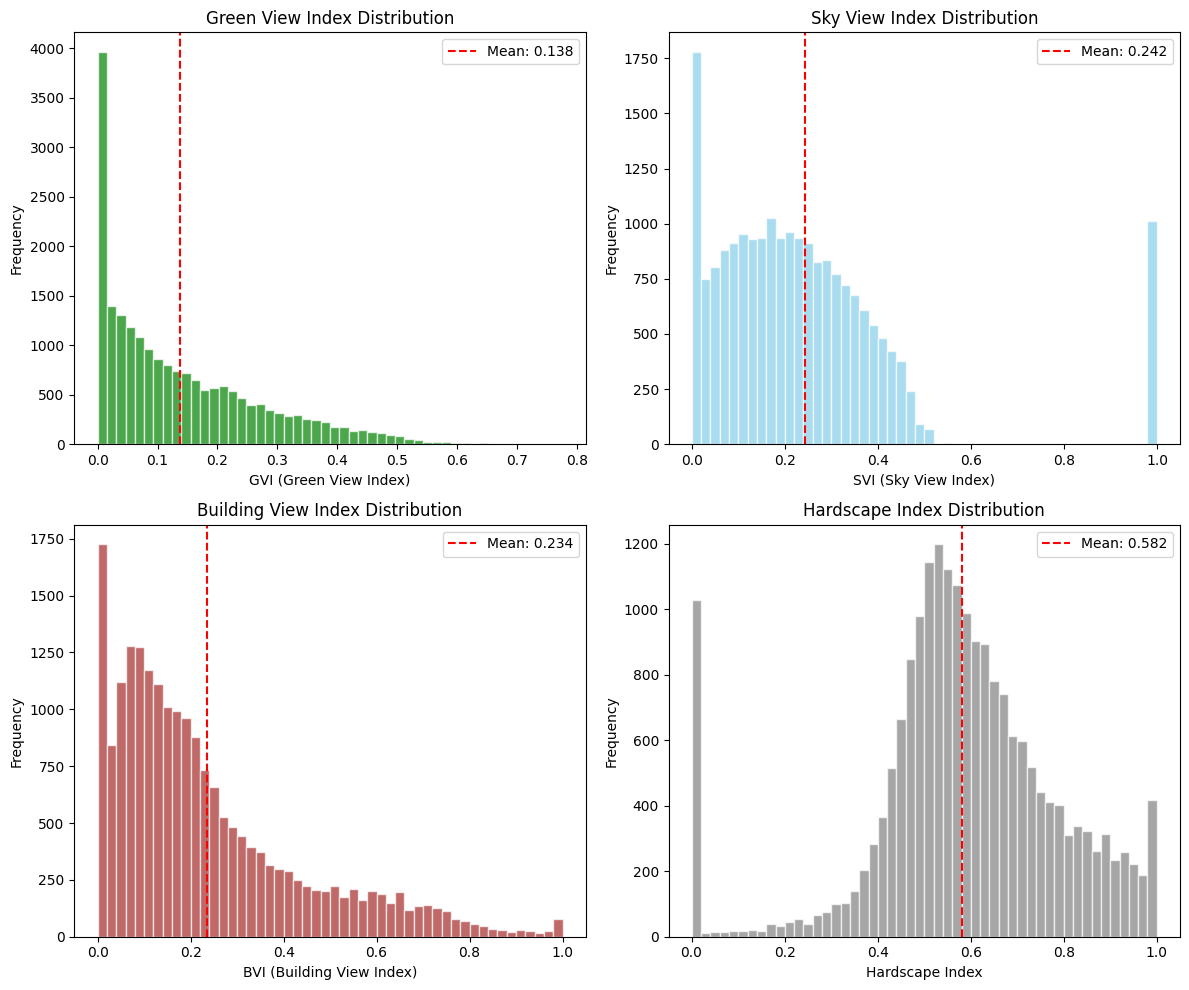

In [12]:
# Plot histograms of view indices.
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

# GVI distribution.
axes[0, 0].hist(df_out["gvi"], bins = 50, color = "green", alpha = 0.7, edgecolor = "white")
axes[0, 0].axvline(df_out["gvi"].mean(), color = "red", linestyle = "--", label = f"Mean: {df_out['gvi'].mean():.3f}")
axes[0, 0].set_xlabel("GVI (Green View Index)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Green View Index Distribution")
axes[0, 0].legend()

# SVI distribution.
axes[0, 1].hist(df_out["svi"], bins = 50, color = "skyblue", alpha = 0.7, edgecolor = "white")
axes[0, 1].axvline(df_out["svi"].mean(), color = "red", linestyle = "--", label = f"Mean: {df_out['svi'].mean():.3f}")
axes[0, 1].set_xlabel("SVI (Sky View Index)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Sky View Index Distribution")
axes[0, 1].legend()

# BVI distribution.
axes[1, 0].hist(df_out["bvi"], bins = 50, color = "brown", alpha = 0.7, edgecolor = "white")
axes[1, 0].axvline(df_out["bvi"].mean(), color = "red", linestyle = "--", label = f"Mean: {df_out['bvi'].mean():.3f}")
axes[1, 0].set_xlabel("BVI (Building View Index)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Building View Index Distribution")
axes[1, 0].legend()

# Hardscape distribution.
axes[1, 1].hist(df_out["hardscape_index"], bins = 50, color = "gray", alpha = 0.7, edgecolor = "white")
axes[1, 1].axvline(df_out["hardscape_index"].mean(), color = "red", linestyle = "--", label = f"Mean: {df_out['hardscape_index'].mean():.3f}")
axes[1, 1].set_xlabel("Hardscape Index")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Hardscape Index Distribution")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

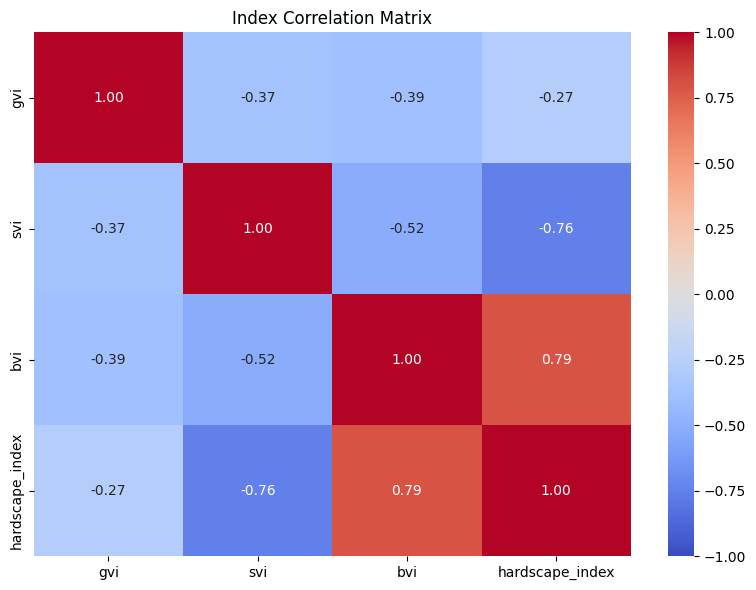

In [13]:
# Correlation matrix of view indices.
index_cols = ["gvi", "svi", "bvi", "hardscape_index"]
corr_matrix = df_out[index_cols].corr()

plt.figure(figsize = (8, 6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "coolwarm",
    center = 0,
    vmin = -1,
    vmax = 1,
    fmt = ".2f"
)
plt.title("Index Correlation Matrix")
plt.tight_layout()
plt.show()